In [1]:
#Manhatten Plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
Temp = pd.read_csv("GWASdata.txt", sep = r"\s+")

df = pd.read_csv("Kunkle_etal_Stage1_results 1 (1).txt", skiprows = 1,sep = r"\s+")
df.columns = Temp.columns
df.columns = Temp.columns
df = pd.concat([df, Temp])
print(df.columns)

Index(['Chromosome', 'Position', 'MarkerName', 'Effect_allele',
       'Non_Effect_allele', 'Beta', 'SE', 'Pvalue'],
      dtype='object')


In [15]:
# Clean data
df = df[["Chromosome", "Position", "Pvalue"]]
df.columns = ["CHR", "BP", "P"]
df = df.dropna(subset=["CHR", "BP", "P"])
df["CHR"] = df["CHR"].astype(int)
df["-log10P"] = -np.log10(df["P"])
print("Done")

Done


/opt/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


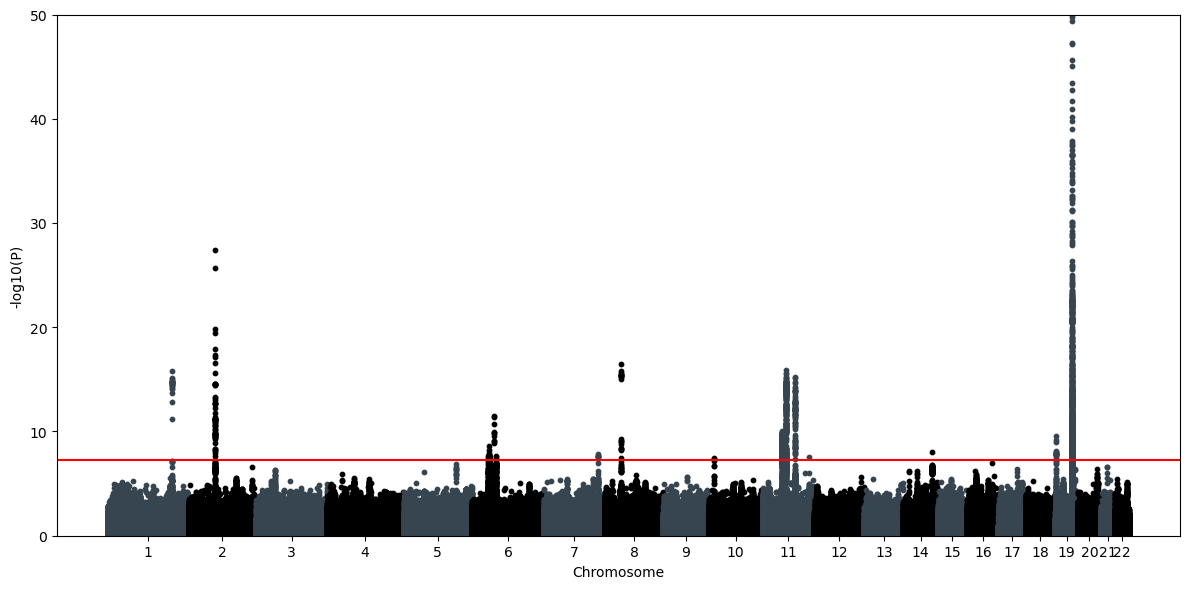

In [20]:
# Sort by chromosome and position
df = df.sort_values(["CHR", "BP"])

# Create cumulative base pair positions
df["ind"] = range(len(df))
df_grouped = df.groupby("CHR")

# Plot
plt.figure(figsize=(12,6))
colors = ["#36454F", "#000000"]  # alternating colors

x_labels = []
x_labels_pos = []

for i, (chrom, group) in enumerate(df_grouped):
    group.plot(kind="scatter",x="ind",y="-log10P",color=colors[i % len(colors)],ax=plt.gca(),s=10)
    
    # midpoint for chromosome label
    x_labels.append(chrom)
    x_labels_pos.append((group["ind"].iloc[0] + group["ind"].iloc[-1]) / 2)

# Genome-wide significance line
plt.axhline(y=-np.log10(5e-8), color="red")

# Formatting
plt.xticks(x_labels_pos, x_labels)
plt.xlabel("Chromosome")
plt.ylim(0,50)
plt.ylabel("-log10(P)")
plt.tight_layout()

plt.show()